In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
"""
1. Injection of global noise via phase shifts and
by frequency offsets.

2. Injection of global and local noise via single
addressing beams causing stark shifts.

"""

import graph_style as gs
import fig_helper as fh
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

gs.set_graph_style(1)

In [12]:
def plot_data_fit(ax, df, m, popt):
    x_min = 1
    model_func = m.model
    x_max = max(df["Clifford Length"]) * 2
    if m.name == "GT" or m.name == "PTM" or m.name == "Clifford" or m.name == "SO3":
        reshape_fac = 4
        ax.hlines(0.25, x_min, x_max, color=gs.get_color(5), linestyle="--", alpha=0.8)
        ax.hlines(0.5, x_min, x_max, color=gs.get_color(5), linestyle="--", alpha=0.8)
        ax.hlines(0.333, x_min, x_max, color=gs.get_color(2), linestyle="--", alpha=0.8)

        ax.errorbar(df["Clifford Length"], df["P00"], yerr=df["P00 Std"], fmt="^", label="$\\mathcal{P}_{SS}$", color=gs.get_color(1), alpha=0.8)
        ax.errorbar(df["Clifford Length"], df["P11"], yerr=df["P11 Std"], fmt="v", label="$\\mathcal{P}_{FF}$", color="#017517", alpha=0.8)
        P0110 = [a+b for a, b in zip(df["P01"], df["P10"])]
        P0110_std = [np.sqrt(a**2 + b**2) for a, b in zip(df["P01 Std"], df["P10 Std"])]
        ax.errorbar(df["Clifford Length"], P0110, yerr=P0110_std, fmt="s", label="$\\mathcal{P}_{SF}+\\mathcal{P}_{FS}$", color=gs.get_color(3), alpha=0.8)
        x_fit = np.logspace(np.log10(x_min), np.log10(x_max), 100)        
        P_fit = model_func(x_fit, *popt).reshape(reshape_fac, -1)
        ax.plot(x_fit, P_fit[0], color=gs.get_color(1), alpha=gs.get_alpha(), linestyle="-")
        ax.plot(x_fit, P_fit[3], color="#017517", alpha=gs.get_alpha(), linestyle="-")
        P0110_fit = P_fit[1] + P_fit[2]
        ax.plot(x_fit, P0110_fit, color=gs.get_color(3), alpha=gs.get_alpha(), linestyle="-")
        ax.set_ylabel("Populations")
        ax.legend(loc="upper right")
        ax.set_ylim(-0.05, 1.0)


    elif m.name == "GTRed":
        reshape_fac = 3
        ax.hlines(1/3, x_min, x_max, color=gs.get_color(2), linestyle="--", alpha=0.8)
        ax.hlines(0, x_min, x_max, color=gs.get_color(5), linestyle="--", alpha=0.8)

        pops = [df["P00"], df["P01"], df["P10"], df["P11"]]
        errs = [df["P00 Std"], df["P01 Std"], df["P10 Std"], df["P11 Std"]]
        pops, errs = m.convert_pops(pops, errs)
        Par, P1, P2 = pops
        Par_err, P1_err, P2_err = errs
        ax.errorbar(df["Clifford Length"], Par, yerr=Par_err, fmt="^", label="$\\Pi$", color="black")
       
        x_fit = np.logspace(np.log10(x_min), np.log10(x_max), 100)        
        P_fit = model_func(x_fit, *popt).reshape(reshape_fac, -1)
        ax.plot(x_fit, P_fit[0], color="black", alpha=gs.get_alpha(), linestyle="-")
        ax.set_ylabel("Parity, $\\Pi$")
        ax.set_ylim(-0.05, 0.9)
        ax.set_yticks([0, 1/3, 2/3])
        ax.set_yticklabels(["0", r"$\frac{1}{3}$", r"$\frac{2}{3}$"])

    ax.set_xlim(x_min, x_max)
    
    ax.set_xscale("log")
    # place legend in upper right corner


C:\Users\webbd\AppData\Local\Temp\ipykernel_31900\4207340801.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_visible(False)
C:\Users\webbd\AppData\Local\Temp\ipykernel_31900\4207340801.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_visible(False)
C:\Users\webbd\AppData\Local\Temp\ipykernel_31900\4207340801.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


$\varepsilon_\mathrm{corr}$: 0.0514 ± 0.0031
$\varepsilon_{L}$: 0.0010 ± 0.0011
$\varepsilon_{R}$: 0.0000 ± 0.0011
SPAM: 0.0000 ± 0.0051
Clifford Error Left: 0.0524 ± 0.0033
Clifford Error Right: 0.0514 ± 0.0033
Parity Fit Parameters:
$\varepsilon_\mathrm{corr}$: 0.0429 ± 0.0029
$\varepsilon_{L}$: 0.0016 ± 0.0001


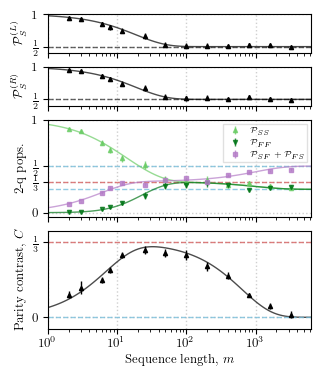

In [14]:
m = fh.SO3Model()

fig_width = gs.get_fig_width()*246/510
fig_height = gs.get_fig_width()*246/510 * 1.2

from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(fig_width, fig_height))
grids = GridSpec(4, 2, figure=fig, height_ratios=[1, 1, 2.5, 2.5], hspace=0.20)

ax1 = fig.add_subplot(grids[0, :])
ax2 = fig.add_subplot(grids[1, :], sharex=ax1)
ax3 = fig.add_subplot(grids[2, :], sharex=ax1)
ax4 = fig.add_subplot(grids[3, :], sharex=ax1)


# Plot two qubit decays
date = "2026-02-05"
rid = 93319 # 10 kHz detuning dataset
sim_outcomes = [1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, ]
df, popt, pcov = m.rb_to_fits(date, rid, sim_outcomes)
x_min = 1
x_max = max(df["Clifford Length"]) * 2
sim_line = np.logspace(np.log10(x_min), np.log10(x_max), 100)
plot_data_fit(ax3, df, m, popt)
ax3.set_yticks([0, 1/3, 1/2, 1.0])
ax3.set_yticklabels(["0", r"$\frac{1}{3}$", r"$\frac{1}{2}$", "1"])
ax3.set_ylabel("2-q pops.")

# Plot single qubit decays
x, P_L, P_L_err, P_R, P_R_err = m.get_single_qubit_pops(df)
e_cL, e_cR = m.get_single_qubit_errors(popt)
spam = popt[3]
P_L_fit = [m.single_qubit_model(i, e_cL, spam) for i in sim_line]
P_R_fit = [m.single_qubit_model(i, e_cR, spam) for i in sim_line]
for ax, P, P_err, P_fit, label in zip([ax1, ax2], [P_L, P_R], [P_L_err, P_R_err], [P_L_fit, P_R_fit], ["$\\mathcal{P}_S^{(L)}$", "$\\mathcal{P}_S^{(R)}$"]):
    ax.hlines(0.5, x_min, x_max, color="black", linestyle="--", alpha=0.6)
    ax.errorbar(df["Clifford Length"], P, yerr=P_err, fmt="^",color="black", alpha=1.0)
    ax.plot(sim_line, P_fit, color="black", alpha=gs.get_alpha(), linestyle="-")
    # turn off legend
    ax.legend().set_visible(False)
    ax.set_yticks([0.5, 1.0])
    ax.set_yticklabels(["$\\frac{1}{2}$", "1"])
    ax.set_ylim(0.4, 1.0)
    ax.set_ylabel(label)

# plot parities
# data from: 
cliffords = [50, 25, 12,  100, 200, 400, 800, 6, 3, 1600, 8, 2, 3200]
par_contrast = np.array([
    0.5738,
    0.5967,
    0.5525,
    0.5551,
    0.4517,
    0.3674,
    0.1941,
    0.3287,
    0.2634,
    0.1025,
    0.4192,
    0.1997,
    0.0213,
])*1/2
par_contrast_err = np.array([
    0.0343,
    0.0344,
    0.0273,
    0.0433,
    0.0373,
    0.0309,
    0.0118,
    0.0274,
    0.0577,
    0.0261,
    0.0268,
    0.0318,
    0.0304,
])*1/2

p_parity = ax4.errorbar(cliffords, par_contrast, yerr=par_contrast_err, color="black", fmt="^")

depol_popt = popt[1] + popt[2]  # Total depolarizing error from the previous fit

popt_infer = [popt[0], depol_popt]  # Initial guess for l and g from the previous fit
# combine index 1 and 2 of the covariance matrix to get the variance for the total depolarizing error
pcov_infer_diagonal = np.diag([pcov[0, 0], pcov[1, 1] + pcov[2, 2] + 2*pcov[1, 2]])  # Variance for the initial guess
# get covariance between index 0 and the total depolarizing error by summing the covariances of index 0 with index 1 and index 2
pcov_infer_offdiag = pcov[0, 1] + pcov[0, 2]  # Covariance between l and the total depolarizing error
pcov_infer = np.array([[pcov_infer_diagonal[0, 0], pcov_infer_offdiag], [pcov_infer_offdiag, pcov_infer_diagonal[1, 1]]])  # Covariance matrix for the initial guess
popt_par, pcov_par = curve_fit(m.parity_model, cliffords, par_contrast, p0=popt_infer)

fitted_parity_decay = m.parity_model(sim_line, *popt_infer)
fitted_parity_par = m.parity_model(sim_line, *popt_par)
# plot error bars for the fit by shading the area between the upper and lower bounds of the fit using MC method
# best-fit parameters and covariance from your fit
# draw correlated parameter samples
n_samples = 5000
param_samples = np.random.multivariate_normal(popt_infer, pcov_infer, size=n_samples)

# evaluate model for each sample
y_samples = np.array([m.parity_model(sim_line, *p) for p in param_samples])

# central 68% band, roughly 1-sigma
y_lo = np.percentile(y_samples, 16, axis=0)
y_hi = np.percentile(y_samples, 84, axis=0)

#plt.fill_between(sim_line, y_lo, y_hi, alpha=0.4, color="gray")

ax4.plot(sim_line, fitted_parity_par, color="black", alpha=gs.get_alpha(), linestyle="-")
ax4.hlines(1/3, x_min, x_max, color=gs.get_color(2), linestyle="--", alpha=0.8)
ax4.hlines(0, x_min, x_max, color=gs.get_color(5), linestyle="--", alpha=0.8)
ax4.set_ylabel("Parity contrast, $C$")
ax4.set_ylim(-0.05, 1/3+0.05)
ax4.set_yticks([0, 1/3])
ax4.set_yticklabels(["0", r"$\frac{1}{3}$"])
ax4.set_xlabel("Sequence length, $m$")

# Save the figure
# Optional: hide repeated tick labels
plt.setp(ax1.get_xticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)
plt.setp(ax3.get_xticklabels(), visible=False)
plt.tight_layout()
f_path = "..\\pdf_figure\\f2_depol_corr.pdf"
fig.savefig(f_path)


# Print results

param1, param2, param3, param4 = popt
param1_err, param2_err, param3_err, param4_err = np.sqrt(np.diag(pcov))

print(f"{m.p1_name}: {param1:.4f} ± {param1_err:.4f}")
print(f"{m.p2_name}: {param2:.4f} ± {param2_err:.4f}")
print(f"{m.p3_name}: {param3:.4f} ± {param3_err:.4f}")
print(f"{m.p4_name}: {param4:.4f} ± {param4_err:.4f}")

err_clifford_L = param1 + param2
err_clifford_R = param1 + param3
err_clifford_L_err = np.sqrt(param1_err**2 + param2_err**2)
err_clifford_R_err = np.sqrt(param1_err**2 + param3_err**2)
print(f"Clifford Error Left: {err_clifford_L:.4f} ± {err_clifford_L_err:.4f}")
print(f"Clifford Error Right: {err_clifford_R:.4f} ± {err_clifford_R_err:.4f}")


par_param1, par_param2 = popt_par
par_param1_err, par_param2_err = np.sqrt(np.diag(pcov_par))
print(f"Parity Fit Parameters:")
print(f"{m.p1_name}: {par_param1:.4f} ± {par_param1_err:.4f}")
print(f"{m.p2_name}: {par_param2:.4f} ± {par_param2_err:.4f}")


dict_keys(['ndscan.rid_93292.analysis_results', 'ndscan.rid_93292.annotations', 'ndscan.rid_93292.axes', 'ndscan.rid_93292.channels', 'ndscan.rid_93292.completed', 'ndscan.rid_93292.fragment_fqn', 'ndscan.rid_93292.ndscan_schema_revision', 'ndscan.rid_93292.online_analyses', 'ndscan.rid_93292.points.axis_0', 'ndscan.rid_93292.points.axis_1', 'ndscan.rid_93292.points.channel_crystal_check_readout_counts', 'ndscan.rid_93292.points.channel_crystal_check_readout_is_brights', 'ndscan.rid_93292.points.channel_crystal_check_readout_p_00', 'ndscan.rid_93292.points.channel_crystal_check_readout_p_01_10', 'ndscan.rid_93292.points.channel_crystal_check_readout_p_11', 'ndscan.rid_93292.points.channel_crystal_check_readout_parity', 'ndscan.rid_93292.points.channel_crystal_check_readout_parity_err', 'ndscan.rid_93292.points.channel_expected_outcome', 'ndscan.rid_93292.points.channel_measurement_camera_readout_p', 'ndscan.rid_93292.points.channel_measurement_camera_readout_p_0', 'ndscan.rid_93292.poi

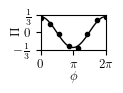

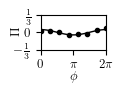

In [39]:
# Parity scan inset
def unpack_parity(rid, day):
    f = fh.load_result(rid=rid, day=day, experiment="fastgates")
    print(f["datasets"].keys())
    try:
        x = np.array(f["datasets"][f"ndscan.rid_{rid}.points.axis_0"])  # num cliffs
        y = np.array(f["datasets"][f"ndscan.rid_{rid}.points.axis_1"])  # seed?
        z = np.array(f["datasets"][f"ndscan.rid_{rid}.points.axis_2"])  # phase turns?

    except KeyError:
        x = None
        y = np.array(f["datasets"][f"ndscan.rid_{rid}.points.axis_0"])  # num cliffs
        z = np.array(f["datasets"][f"ndscan.rid_{rid}.points.axis_1"])  # seed?

    parity = np.array(
        f["datasets"][f"ndscan.rid_{rid}.points.channel_rbm_readout_parity"]
    )
    parity_err = np.array(
        f["datasets"][f"ndscan.rid_{rid}.points.channel_rbm_readout_parity_err"]
    )
    p = parity, parity_err
    return x, y, z, p


def average_parity(seeds, phases, p):
    unique_seeds = np.sort(np.unique(seeds))
    unique_phases = np.sort(np.unique(phases))
    parity_array = np.zeros((len(unique_seeds), len(unique_phases)))
    err_array = np.zeros((len(unique_seeds), len(unique_phases)))

    for i, s in enumerate(unique_seeds):
        mask = seeds == s
        phases_scan = phases[mask]
        sort_ph = np.argsort(phases_scan)
        parity_array[i, :] = p[0][mask][sort_ph]
        err_array[i, :] = p[1][mask][sort_ph]
    avg_parity = np.mean(parity_array, axis=0)
    avg_err = np.sqrt(np.sum(err_array**2, axis=0)) / len(unique_seeds)
    return avg_parity, avg_err, unique_phases


def model_sin(x, a, b, c):
    return a * np.cos(2 * np.pi * x + b) + c


def fit_sin(x, y):
    # Initial guess for the parameters
    initial_guess = [0.5, 0.0, 0]
    limits = ([0, 0, 0], [1, 0.05, 0.05])  # Amplitude between 0 and 1

    # Fit the model to the data
    params, covariance = curve_fit(model_sin, x, y, p0=initial_guess, bounds=limits)

    return params, np.sqrt(np.diag(covariance))


def get_contrast(seeds, phases, p):
    avg_p, avg_err, unique_phases = average_parity(seeds, phases, p)
    params, params_err = fit_sin(unique_phases, avg_p)
    return 2 * params[0], 2 * params_err[0]


def plot_parity_scan_inset(rid, date):
    num_cliffs, seeds, phases, p = unpack_parity(rid, date)

    avg_p, avg_err, unique_phases = average_parity(seeds, phases, p)
    params, params_err = fit_sin(unique_phases, avg_p)
    factor = 1
    fig, ax = plt.subplots(figsize=(1.3*factor, 1*factor))
    ax.errorbar(unique_phases, avg_p, yerr=avg_err, fmt="o", color="black", label="Data")
    x_fit = np.linspace(min(unique_phases), max(unique_phases), 100)
    y_fit = model_sin(x_fit, *params)
    ax.plot(x_fit, y_fit, label="Fitted Sine Wave", color="black", linestyle="-")
    ax.set_yticks([-1/3, 0, 1/3], [r"$-\frac{1}{3}$", "0", r"$\frac{1}{3}$"])
    # x tickks at 0, 0.5, 1
    ax.set_xticks([0, 0.5, 1], ["0", "$\\pi$", "$2\\pi$"])
    ax.set_ylim(-1/3, 1/3)
    ax.set_xlim(0, 1)
    ax.set_xlabel("$\\phi$", labelpad=1)
    ax.set_ylabel("$\\Pi$", labelpad=-5)
    print("Fitted parameters:", params)
    print("Parameter errors:", params_err)
    ax.grid(False)
    return fig, ax, params, params_err


date = "2026-02-05"
rid = 93292 # 25 cliffs
fig, ax, params, params_err = plot_parity_scan_inset(rid, date)
# tigt layout and save the figure
plt.tight_layout()
plt.savefig("..\\pdf_figure\\f2_parity_inset_high.pdf", transparent=True)

rid = 93307 # 1600 cliffs
fig, ax, params, params_err = plot_parity_scan_inset(rid, date)
# tigt layout and save the figure
plt.tight_layout()
plt.savefig("..\\pdf_figure\\f2_parity_inset_low.pdf", transparent=True)

In [13]:
theta_1 = par_param2
theta_1_err = par_param2_err
def theta_to_error(theta, theta_err):
    p = 1 - (1 + 2*np.cos(theta_1)) / 3
    p_err = (2/3)*np.sin(theta_1) * theta_err
    return p, p_err

def theta_1_plus_theta_2(theta_1, theta_1_err, theta_2, theta_2_err):

p_error, p_error_err = theta_to_error(theta_1, theta_1_err)
print(f"Error per Clifford from parity fit: {p_error:.5f} ± {p_error_err:.5f}")


IndentationError: expected an indented block after function definition on line 8 (1354614495.py, line 10)

$\theta_{\mathrm{com}}$: 0.4024 ± 0.0119
$\theta_{\mathrm{diff}}$: 0.0260 ± 0.0019
$\theta_{1}$: 0.4050 ± 0.0180
$\theta_{2}$: 0.3947 ± 0.0177


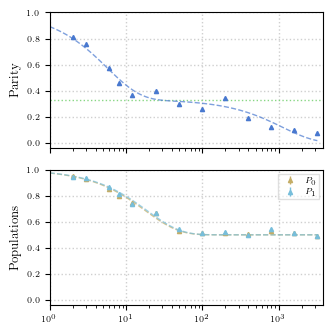

In [16]:
# test new odd, even model
def plot_even_odd_fit(ax, df, model_func, popt):
    x_min = 1
    x_max = max(df["Clifford Length"]) * 1.2
    ax.hlines(1/3, x_min, x_max, color=gs.get_color(1), linestyle=":", alpha=0.8)
    #ax.hlines(0.5, x_min, x_max, color=gs.get_color(2), linestyle=":", alpha=0.8)
    #ax.hlines(2/3, x_min, x_max, color=gs.get_color(1), linestyle=":", alpha=0.8)
    
    pops, errs = m.convertpops(df["P00"], df["P01"], df["P10"], df["P11"])
    Par, P0, P1 = pops
    Par_err, P0_err, P1_err = errs
    ax.errorbar(df["Clifford Length"], Par, yerr=Par_err, fmt="^", label="$\\Pi$", color=gs.get_color(0))

    x_fit = np.logspace(np.log10(x_min), np.log10(max(df["Clifford Length"])), 100)
    P_fit = model_func(x_fit, *popt).reshape(3, -1)
    
    ax.plot(x_fit, P_fit[0], color=gs.get_color(0), alpha=gs.get_alpha())
    
    ax.set_ylabel("Parity")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(-0.04, 1.0)
    ax.set_xscale("log")
    # place legend in upper right corner
    #ax.legend(loc="upper right")

def single_q_fit(ax, df, model_func, popt):
    x_min = 1
    x_max = max(df["Clifford Length"]) * 1.2

    pops, errs = m.convertpops(df["P00"], df["P01"], df["P10"], df["P11"])
    Par, P0, P1 = pops
    Par_err, P0_err, P1_err = errs
    ax.errorbar(df["Clifford Length"], P0, yerr=P0_err, fmt="^", label="$P_{0}$", color=gs.get_color(4))
    ax.errorbar(df["Clifford Length"], P1, yerr=P1_err, fmt="^", label="$P_{1}$", color=gs.get_color(5))

    x_fit = np.logspace(np.log10(x_min), np.log10(max(df["Clifford Length"])), 100)
    P_fit = model_func(x_fit, *popt).reshape(3, -1)

    ax.plot(x_fit, P_fit[1], color=gs.get_color(4), alpha=gs.get_alpha())
    ax.plot(x_fit, P_fit[2], color=gs.get_color(5), alpha=gs.get_alpha())
    
    ax.set_ylabel("Populations")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(-0.04, 1.0)
    ax.set_xscale("log")
    # place legend in upper right corner
    ax.legend(loc="upper right")

m = fh.GTReducedModel()
fig_width = gs.get_fig_width()*246/510
fig_height = gs.get_fig_width()*246/510

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(fig_width, fig_height), sharex=True)

date = "2026-02-05"
rid = 93319
sim_outcomes = [1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, ]
df, popt, pcov = m.rb_to_fits(date, rid, sim_outcomes)
plot_even_odd_fit(ax1, df, m.model, popt)
single_q_fit(ax2, df, m.model, popt)
# print fitted parameters
param1, param2, param3, param4 = popt
param1_err, param2_err, param3_err, param4_err = np.sqrt(np.diag(pcov))
print(f"{m.p1_name}: {param1:.4f} ± {param1_err:.4f}")
print(f"{m.p2_name}: {param2:.4f} ± {param2_err:.4f}")
print(f"{m.p3_name}: {param3:.4f} ± {param3_err:.4f}")
print(f"{m.p4_name}: {param4:.4f} ± {param4_err:.4f}")

In [ ]:
$\theta_{\mathrm{com}}$: 0.4024 ± 0.0115
$\theta_{\mathrm{diff}}$: 0.0260 ± 0.0019
$\theta_{1}$: 0.4050 ± 0.0124
$\theta_{2}$: 0.3947 ± 0.0121

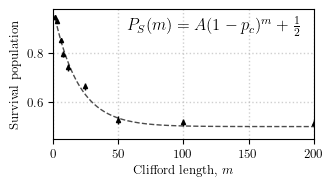

In [17]:
# plot single qubit fits
fig_width = gs.get_fig_width()*246/510
fig_height = gs.get_fig_width()*140/510
m = fh.GTReducedModel()
fig, ax1 = plt.subplots(1, 1, figsize=(fig_width, fig_height))
date = "2026-02-05"
rid = 93319
sim_outcomes = [1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, ]
df, popt, pcov = m.rb_to_fits(date, rid, sim_outcomes)
def plt_single_q_fits(ax, df):
    P0 = df["P00"] + df["P01"]
    x = df["Clifford Length"]

    def single_exp_model(x, A, B):
        return A * B**x + 1/2
    popt0, pcov0 = curve_fit(single_exp_model, x, P0, p0=[0.5, 0.01], bounds=([0, 0], [1, 1]))
    x_fit = np.logspace(np.log10(min(x)), np.log10(max(x)), 100)
    P0_fit = single_exp_model(x_fit, *popt0)
    ax.plot(x_fit, P0_fit, color="black", alpha=gs.get_alpha(), label="$P_{0}$ Fit")
    ax.errorbar(x, P0, yerr=np.sqrt(P0*(1-P0)/1000), fmt="^", label="$P_{0}$ Data", color="black")
    ax.set_ylabel("Survival population")
    ax.set_xlabel("Clifford length, $m$")
    ax.set_xlim(0, 200)
    # place fit equation in upper right corner
    ax.text(0.95, 0.95, "$P_S(m) = A(1-p_c)^m + \\frac{1}{2}$", transform=ax.transAxes, ha="right", va="top", fontsize=12)
plt_single_q_fits(ax1, df)
# save figure    
path = "Z:\\FastGates\\Conferences\\2026_GroupRetreat\\k-copyRB\\figures\\"
fig.savefig(path + "single_q_fit.svg", bbox_inches="tight")
    